# Email Classification - Explainability & Audit Trail

Generates SHAP-based explanations for email routing decisions.
This notebook uses the `src.explainability` module for clean, production-ready analysis.

In [91]:
import sys
import os
import pickle
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path
sys.path.append("..")
import importlib
# Import from src modules
importlib.reload(sys.modules['src.ingestion'])
importlib.reload(sys.modules['src.explainability'])
from src.ingestion import build_dataframe, load_labels
from src.preprocessing import add_clean_text_column
from src.features import add_engineered_features
from src.explainability import (
    initialize_shap_explainer,
    generate_compliance_audit_trail,
    compute_global_feature_importance,
    compute_class_feature_importance,
    plot_global_feature_importance,
    plot_class_feature_importance,
    plot_shap_summary,
    plot_waterfall,
    plot_dependence,
    generate_explainability_summary
)

print("  All imports successful")

  All imports successful


In [92]:
import os
from pathlib import Path

# ABSOLUTE PATH to your project
PROJECT_ROOT = Path(r"C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier")

os.chdir(PROJECT_ROOT)

# Define paths
TRAIN_DIR = PROJECT_ROOT / "train"
LABELS_PATH = PROJECT_ROOT / "train_labels.csv"
MODELS_DIR = PROJECT_ROOT / "outputs/models"

print(f"Working directory: {os.getcwd()}")
print(f"  Train exists: {TRAIN_DIR.exists()} → {TRAIN_DIR}")
print(f"  Labels exist: {LABELS_PATH.exists()} → {LABELS_PATH}")
print(f"  Models exist: {MODELS_DIR.exists()} → {MODELS_DIR}")

Working directory: C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier
  Train exists: True → C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier\train
  Labels exist: True → C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier\train_labels.csv
  Models exist: True → C:\Users\elias\OneDrive\Desktop\izasi.ai\Email classifier\outputs\models


In [93]:
# Load training data
train_df = build_dataframe(TRAIN_DIR)
labels_df = load_labels(LABELS_PATH)
train_labeled = train_df.merge(
    labels_df,
    left_on="source_filename",
    right_on="filename",
    how="left"
)

# Add preprocessing and features
train_labeled = add_clean_text_column(train_labeled)
train_labeled = add_engineered_features(train_labeled)

# Extract features and labels
from src.modelling import STRUCTURED_BOOL_COLS, STRUCTURED_NUM_COLS
X = train_labeled[["subject", "message"] + STRUCTURED_BOOL_COLS + STRUCTURED_NUM_COLS]
y = train_labeled["true_category"]

print(f"  Data loaded: {len(train_labeled)} emails")
print(f"  Classes: {y.unique()}")

  Data loaded: 44 emails
  Classes: <StringArray>
[ 'Account Management',               'Other',    'Insurance Claims',
 'Investment Advisory',     'Loan Processing']
Length: 5, dtype: str


In [94]:
# Load the trained calibrated pipeline
with open(MODELS_DIR / "best_model_calibrated.pkl", "rb") as f:
    calibrated_pipeline = pickle.load(f)

with open(MODELS_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

# Fit pipeline on training data (needed for SHAP)
calibrated_pipeline.fit(X, y)

print(f"  Model loaded: {metadata['model_type']}")
print(f"  Text representation: {metadata['text_representation']}")
print(f"  Calibration method: {metadata['calibration_method']}")

  Model loaded: LinearSVC
  Text representation: separated
  Calibration method: Platt Scaling (sigmoid)


## SHAP Explainability Analysis

Initialize SHAP explainer and generate comprehensive interpretability insights.

In [95]:
# Initialize SHAP explainer
explainer, shap_values, feature_names = initialize_shap_explainer(
    calibrated_pipeline, X
)

print(f"  SHAP explainer initialized")
print(f"  SHAP values shape: {shap_values.values.shape}")
print(f"  Feature names: {len(feature_names)} features")

  SHAP explainer initialized
  SHAP values shape: (44, 697, 5)
  Feature names: 697 features


In [96]:
# Compute global feature importance
global_importance_df = compute_global_feature_importance(shap_values, feature_names)

# Save to CSV
global_importance_df.to_csv(MODELS_DIR / "feature_importance_global.csv", index=False)

print(f"  Global feature importance computed")
print(f"\nTop 10 Features:")
print(global_importance_df.head(10))

  Global feature importance computed

Top 10 Features:
                                   feature  importance
696      num_features__question_mark_count    0.146553
694   bool_features__is_internal_signature    0.105556
695  bool_features__is_department_greeting    0.087944
0                                  account    0.059774
32                               insurance    0.042678
15                                   claim    0.042678
56                                 request    0.034275
33                              investment    0.024571
36                                    loan    0.021567
693      bool_features__is_internal_sender    0.018320


DEBUG: top_features shape = (15, 2)
DEBUG: top_features.head() =
                                   feature  importance
696      num_features__question_mark_count    0.146553
694   bool_features__is_internal_signature    0.105556
695  bool_features__is_department_greeting    0.087944
0                                  account    0.059774
32                               insurance    0.042678
DEBUG: importance values = [0.14655322 0.10555562 0.08794363 0.0597737  0.0426779  0.0426779
 0.0342747  0.02457097 0.02156693 0.01831999 0.01015375 0.00916808
 0.00818351 0.00806598 0.00805382]
DEBUG: importance dtype = float64
DEBUG: y_pos = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
DEBUG: len(y_pos) = 15


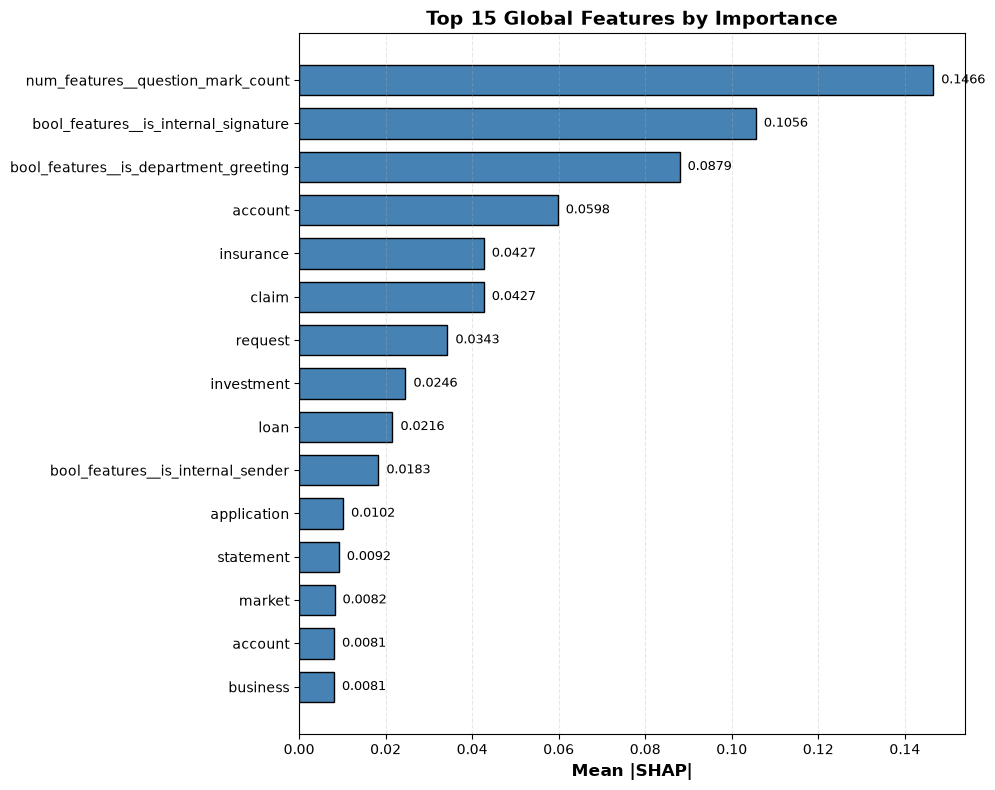

 Plotted top 15 features


In [97]:
# Plot global feature importance
plot_global_feature_importance(global_importance_df, top_n=15)

In [98]:
# Compute per-class feature importance
class_importance_dict = compute_class_feature_importance(
    shap_values,
    feature_names,
    calibrated_pipeline.classes_
)

# Save each class's importance
for class_name, class_df in class_importance_dict.items():
    class_df.to_csv(
        MODELS_DIR / f"feature_importance_{class_name}.csv",
        index=False
    )

print(f"  Per-class feature importance computed for {len(class_importance_dict)} classes")

  Per-class feature importance computed for 5 classes


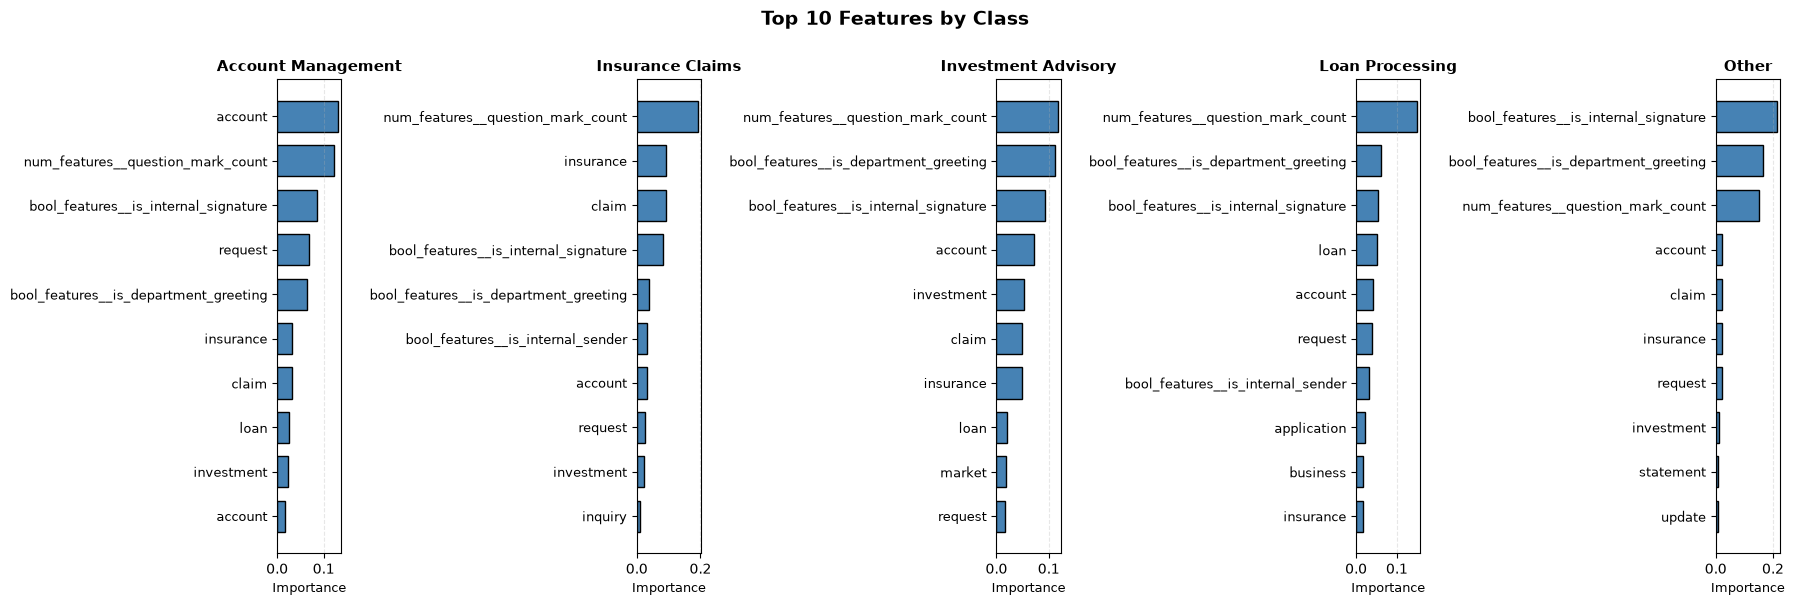

 Plotted top 10 features for 5 classes


In [99]:
# Plot per-class feature importance
plot_class_feature_importance(class_importance_dict, top_n=10)

## SHAP Visualizations

Interactive visualizations of feature impacts and individual predictions.

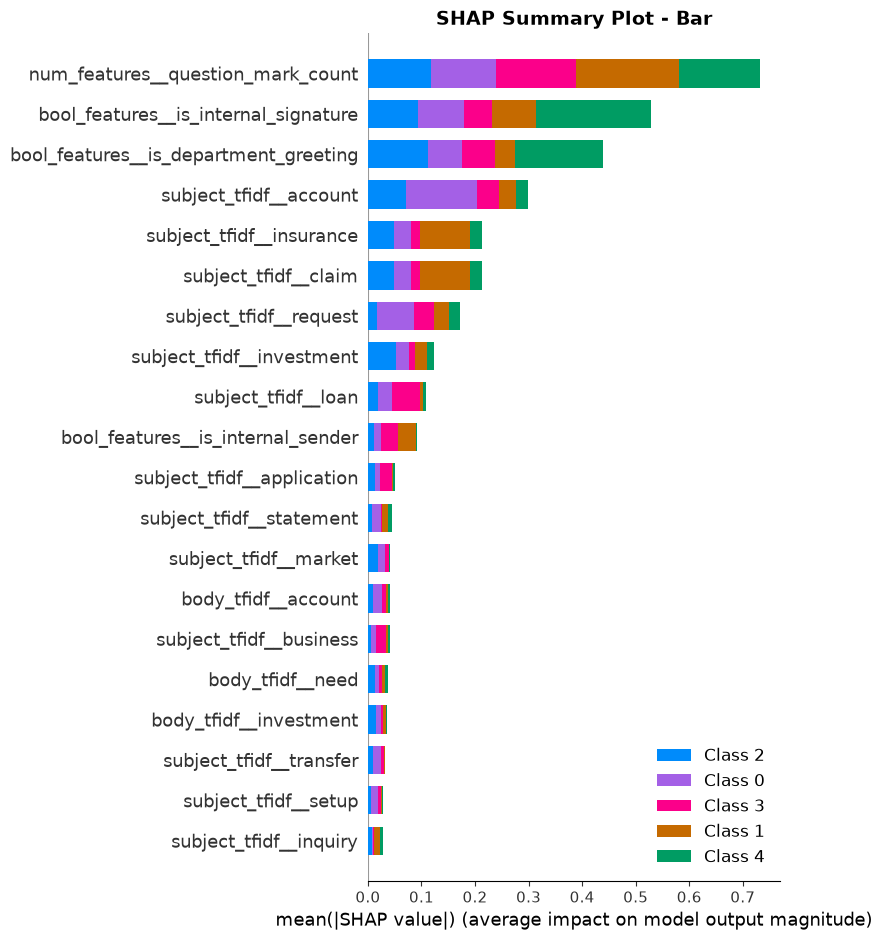

In [100]:
# After initializing explainer
explainer, shap_values, feature_names = initialize_shap_explainer(
    calibrated_pipeline, X
)

# GET THE TRANSFORMED FEATURES for plotting
preprocessor = calibrated_pipeline.named_steps["preprocessor"]
X_transformed = preprocessor.transform(X)

# NOW use X_transformed for plotting
plot_shap_summary(shap_values, X_transformed, feature_names, plot_type="bar")

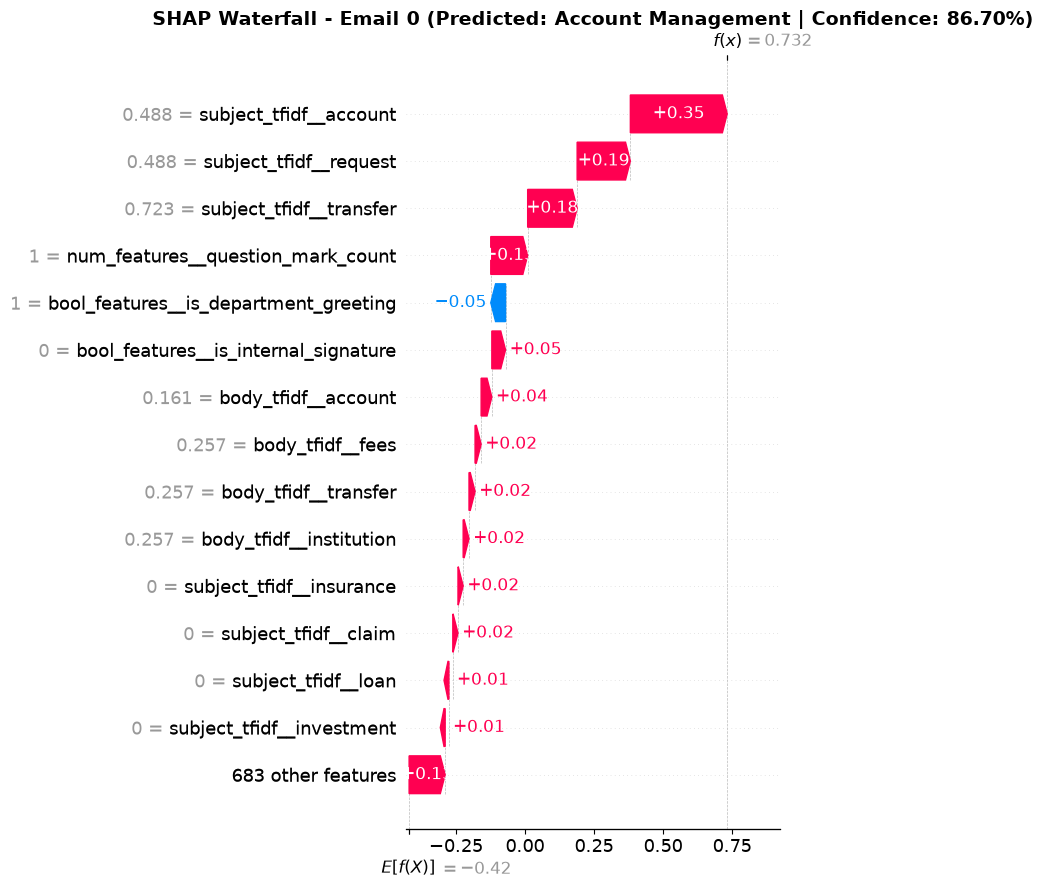

Waterfall plot generated: shows top 15 features contributing to predicting 'Account Management'


In [101]:
# SHAP Waterfall Plot for individual email
# Change sample_idx to explain different emails
sample_idx = 0

try:
    plot_waterfall(
        calibrated_pipeline,
        X,
        explainer,
        shap_values,
        feature_names,
        sample_idx=sample_idx,
        max_display=15
    )
except Exception as e:
    print(f"Error generating waterfall plot: {e}")

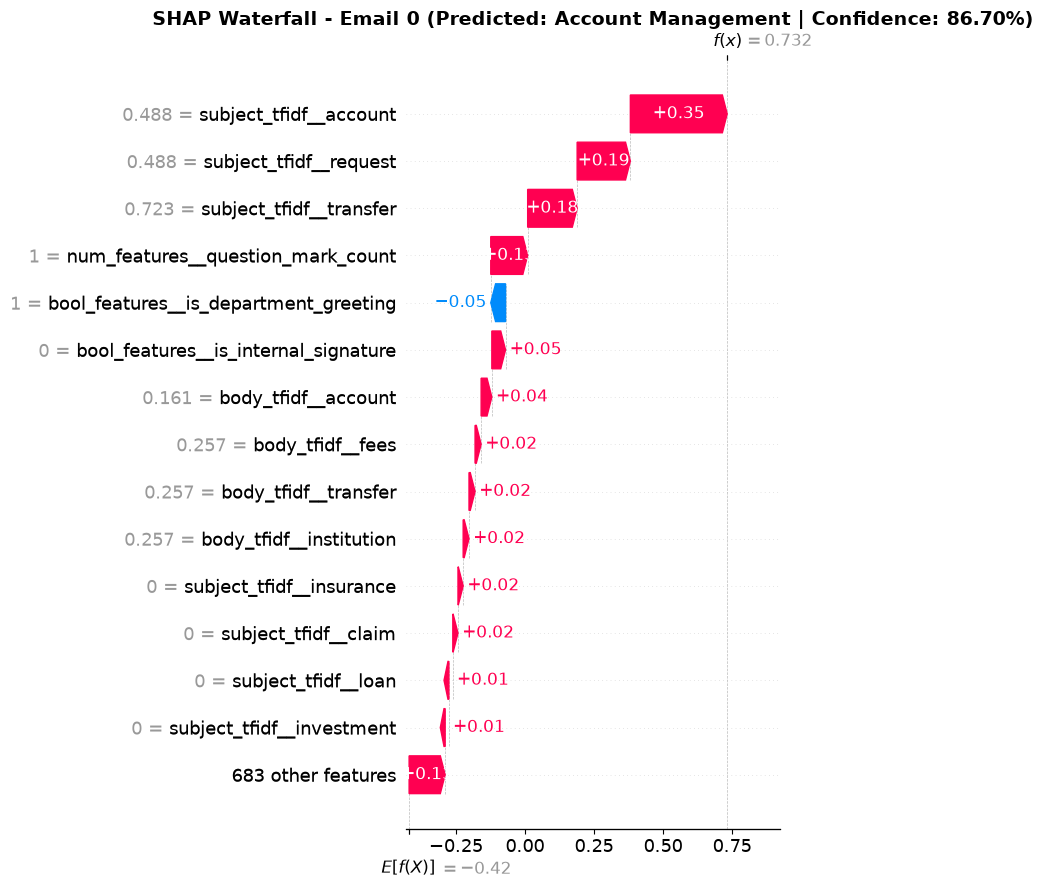

Waterfall plot generated: shows top 15 features contributing to predicting 'Account Management'


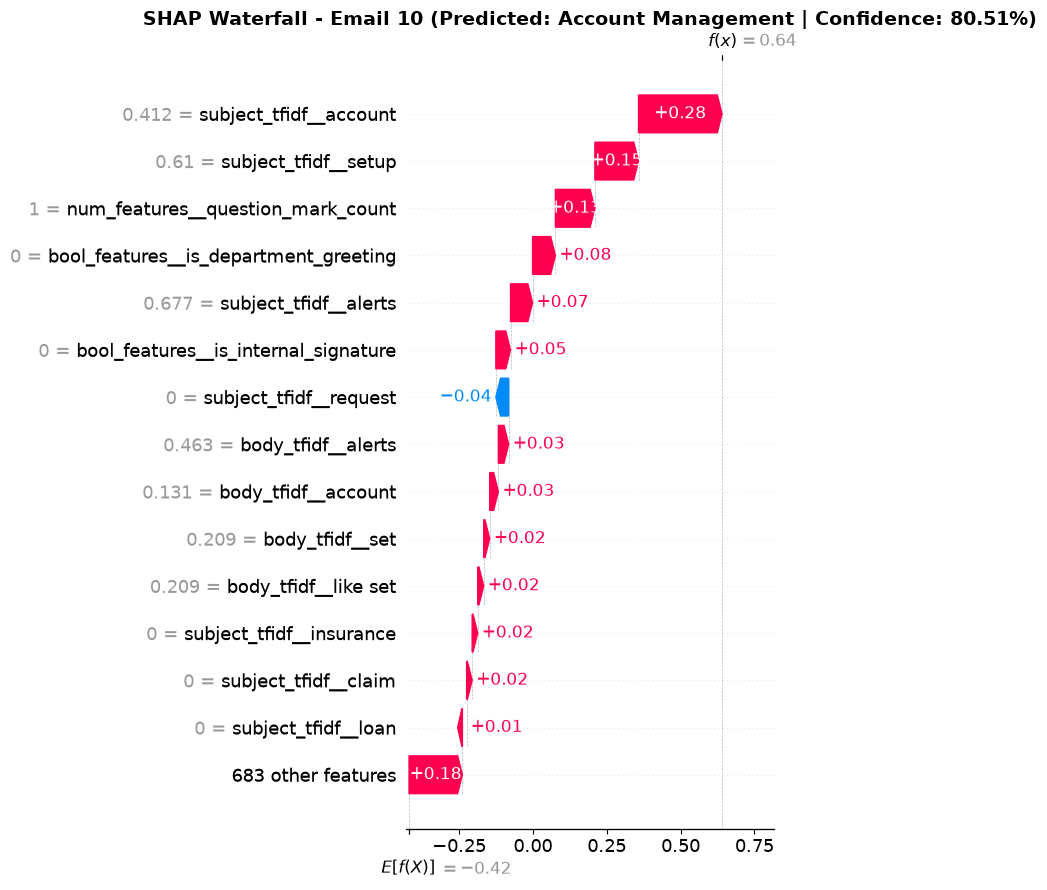

Waterfall plot generated: shows top 15 features contributing to predicting 'Account Management'


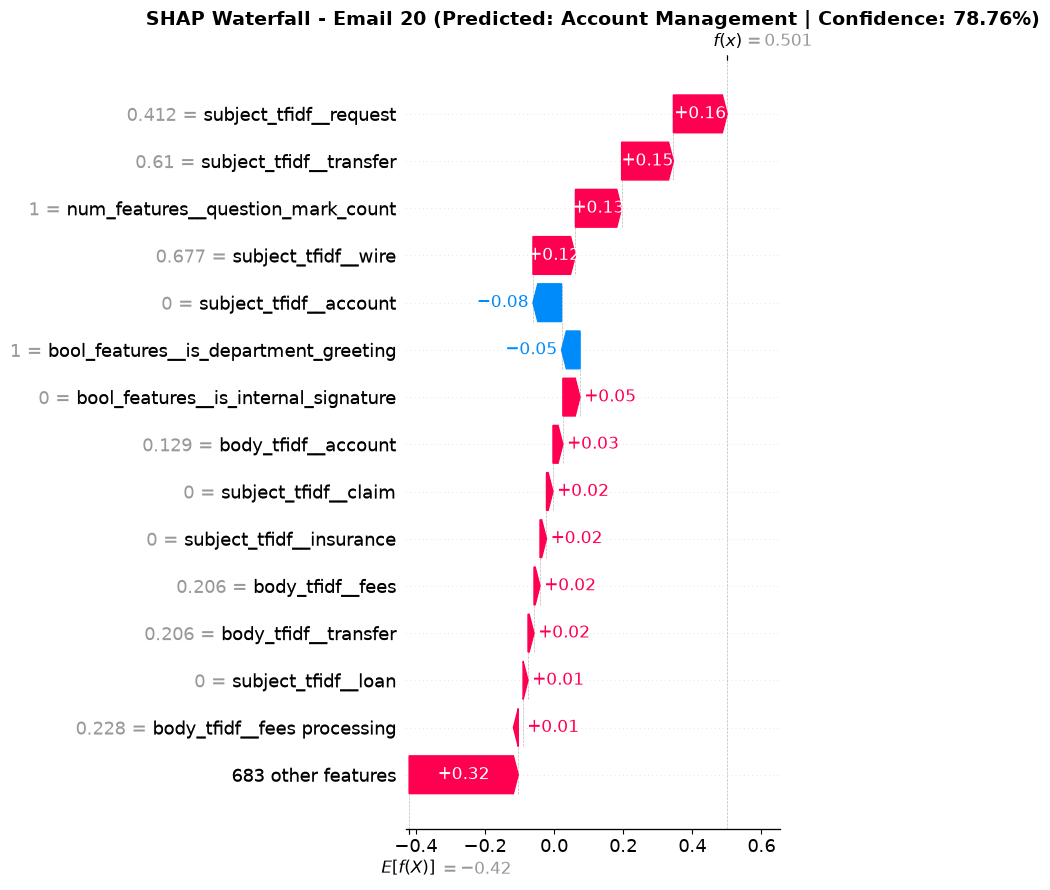

Waterfall plot generated: shows top 15 features contributing to predicting 'Account Management'


In [102]:
# Generate waterfall plots for multiple representative samples
sample_indices = [0, min(10, len(X)-1), min(20, len(X)-1)]

for sample_idx in sample_indices:
    if sample_idx < len(X):
        try:
            plot_waterfall(
                calibrated_pipeline,
                X,
                explainer,
                shap_values,
                feature_names,
                sample_idx=sample_idx,
                max_display=15
            )
        except Exception as e:
            print(f"Error for sample {sample_idx}: {e}")

## Compliance Audit Trail

Generate comprehensive audit trail with SHAP-based explanations for each email.

In [103]:
# Generate compliance audit trail
audit_trail = generate_compliance_audit_trail(
    calibrated_pipeline,
    X,
    top_n=5
)

# Save audit trail
audit_trail.to_csv(MODELS_DIR / "compliance_audit_trail.csv", index=False)

print(f"  Audit trail generated for {len(audit_trail)} emails")
print(f"\nSample audit trail entries:")
print(audit_trail.head(10))

  Audit trail generated for 44 emails

Sample audit trail entries:
   email_id   predicted_category  \
0         0   Account Management   
1         1                Other   
2         2                Other   
3         3     Insurance Claims   
4         4  Investment Advisory   
5         5   Account Management   
6         6                Other   
7         7  Investment Advisory   
8         8     Insurance Claims   
9         9  Investment Advisory   

                                top_driving_features  
0  account (0.35) | request (0.19) | transfer (0....  
1  bool_features__is_internal_signature (0.78) | ...  
2  bool_features__is_internal_signature (0.78) | ...  
3  insurance (0.29) | claim (0.29) | num_features...  
4  review (0.12) | num_features__question_mark_co...  
5  account (0.33) | request (0.18) | verification...  
6  bool_features__is_internal_signature (0.78) | ...  
7  investment (0.23) | review (0.13) | num_featur...  
8  insurance (0.29) | claim (0.29) | num_